In [105]:
import pandas as pd
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [106]:
cardiodata=pd.read_csv('cardio_clean-2.csv')
cardiodata.head()

,id,age,gender,height,weight,bp_systolic,bp_diastolic,cholesterol,gluc,smoke,alco,active,cardio,bmi,age_years,age_cat,age_cat_int
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,21.97,50,45-54,2
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,34.93,55,45-54,2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,23.51,51,45-54,2
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,28.71,48,45-54,2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,23.01,47,45-54,2


In [107]:
X_nc=pd.DataFrame(cardiodata[["bmi","age_years","smoke","active"]])
y=cardiodata['cardio']


In [111]:
# Import train_test_split from sklearn
from sklearn.model_selection import train_test_split

# Split the Dataset into Train and Test
X_train_nc, X_test_nc, y_train, y_test = train_test_split(X_nc, y, test_size = 0.25)

# Check the sample sizes
print("Train Set :", y_train.shape, X_train_nc.shape)
print("Test Set  :", y_test.shape, X_test_nc.shape)

Train Set : (49414,) (49414, 4)
Test Set  : (16472,) (16472, 4)


In [112]:
rf_nc= RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)



In [116]:
depths = [3, 5, 7, 10, 15, 20]

for d in depths:
    rf_nc= RandomForestClassifier(
        n_estimators=300,
        max_depth=d,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
)

    
    rf_nc.fit(X_train_nc, y_train)
    y_pred = rf_nc.predict(X_test_nc)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"Depth {d}: Accuracy = {acc:.4f}")


Depth 3: Accuracy = 0.6198
Depth 5: Accuracy = 0.6249
Depth 7: Accuracy = 0.6236
Depth 10: Accuracy = 0.6200
Depth 15: Accuracy = 0.6034
Depth 20: Accuracy = 0.5913


In [120]:

for d in depths:
    rf_nc= RandomForestClassifier(
        n_estimators=300,
        max_depth=d,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
)

    rf_nc.fit(X_train_nc, y_train)
    y_pred = rf.predict(X_test_nc)

rf_nc.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, random_state=42)

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

for i in range(3):
    plt.figure(figsize=(15,10))
    plot_tree(
        rf.estimators_[i],
        feature_names=X_train.columns,
        class_names=["No Disease", "Disease"],
        filled=True,
        max_depth=2,
        impurity=False,
        proportion=True
    )
    plt.title(f"Tree {i+1} from Random Forest")
    plt.show()

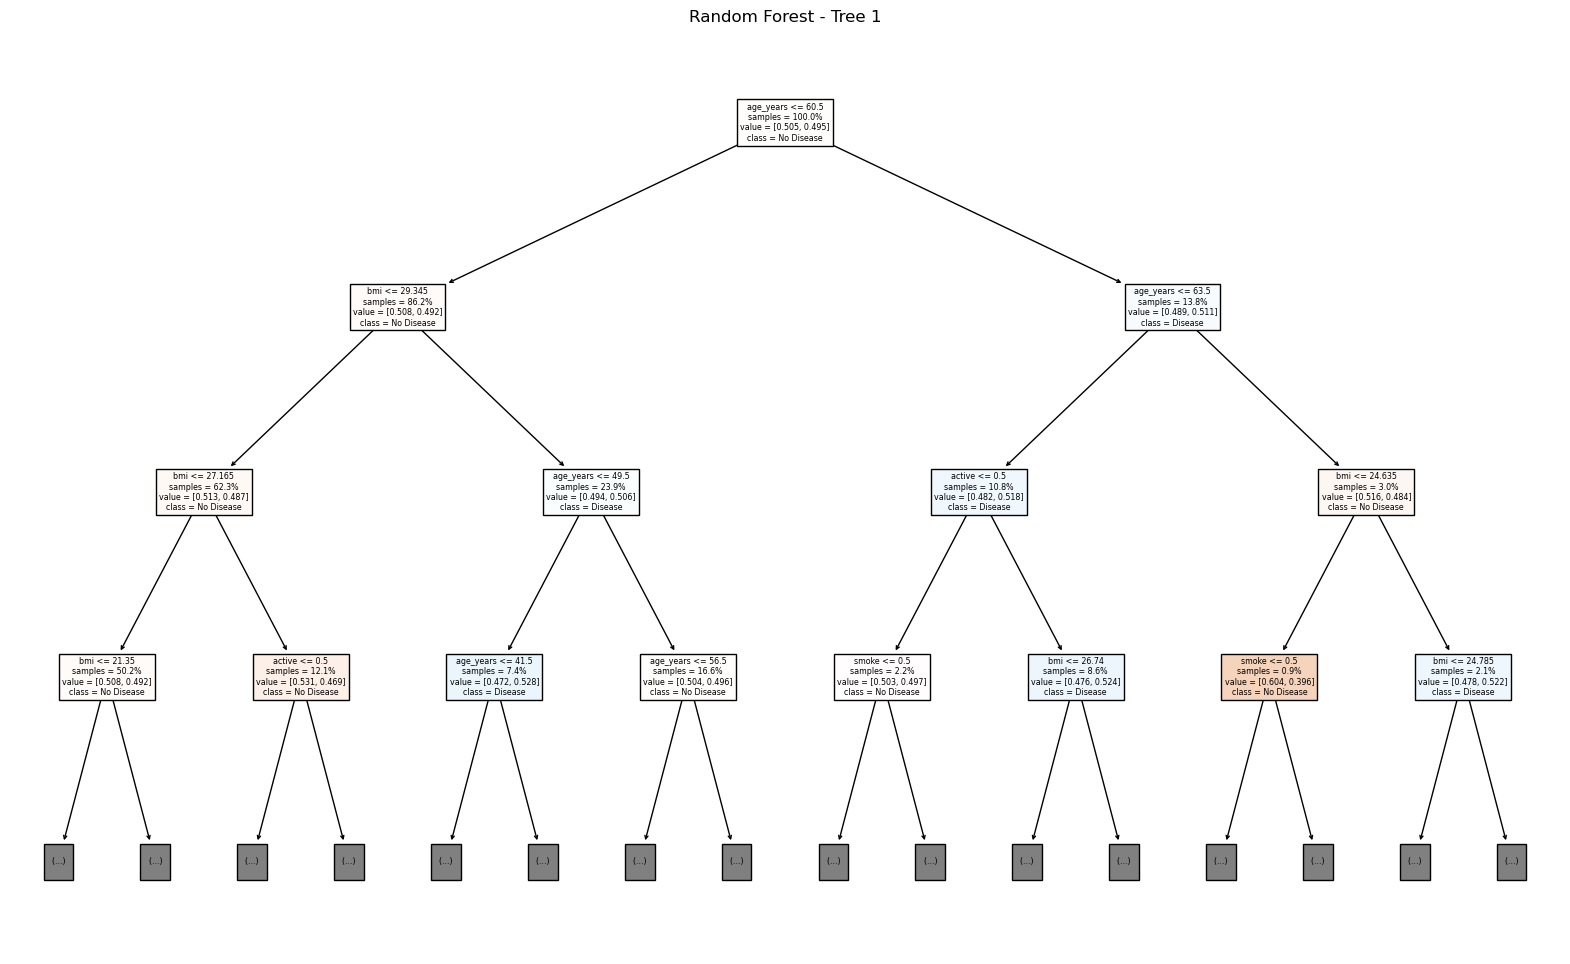

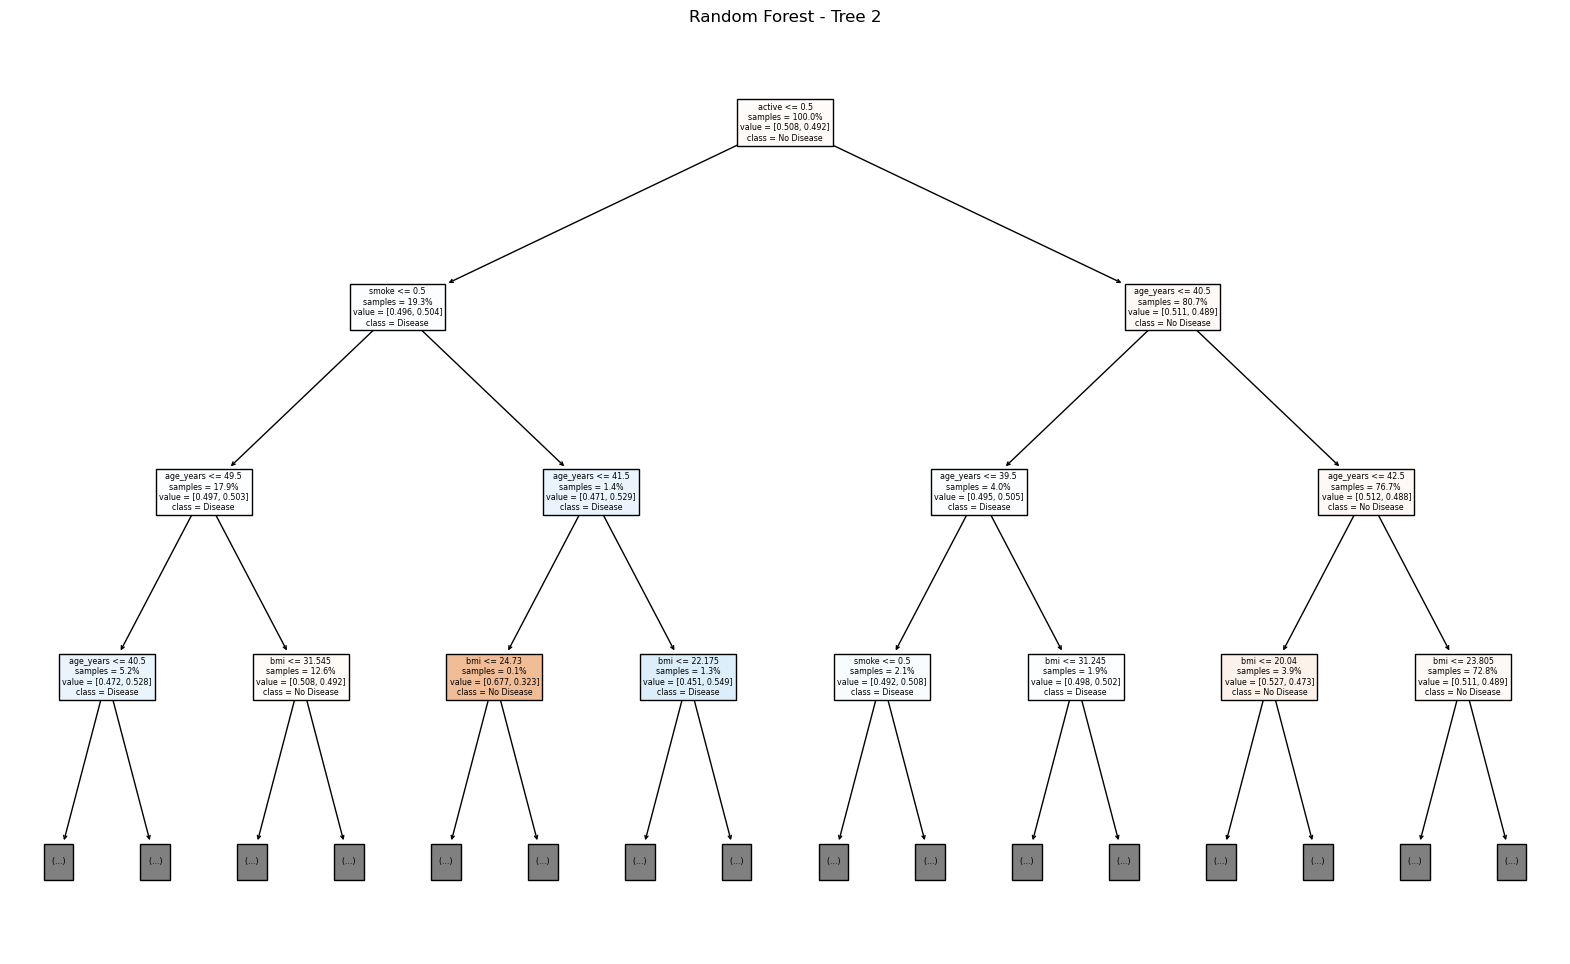

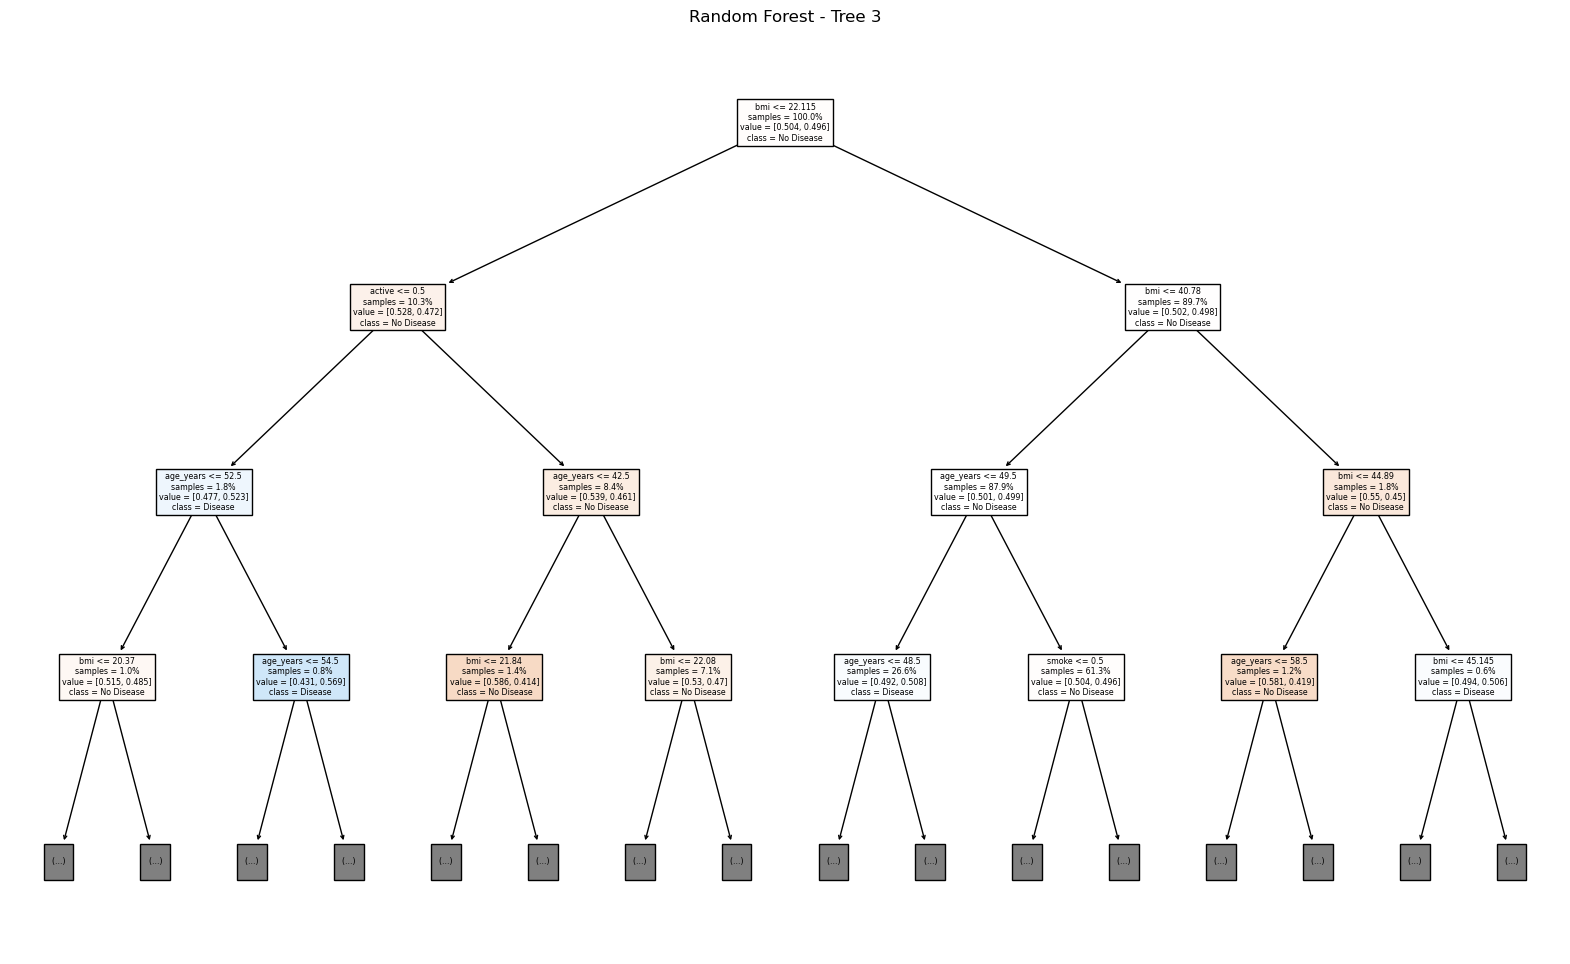

In [121]:
import matplotlib.pyplot as plt 
from sklearn.tree import plot_tree
for i in range(3):
    plt.figure(figsize=(20,12))
    
    plot_tree(
        rf_nc.estimators_[i],
        feature_names=X_train_nc.columns,
        class_names=["No Disease", "Disease"],
        filled=True,
        max_depth=3,
        impurity=False,
        proportion=True
    )
    
    plt.title(f"Random Forest - Tree {i+1}")
    plt.show()

=== Logistic Regression ===
Accuracy: 0.614983001457018
              precision    recall  f1-score   support

           0       0.62      0.63      0.62      8393
           1       0.61      0.60      0.61      8079

    accuracy                           0.61     16472
   macro avg       0.61      0.61      0.61     16472
weighted avg       0.61      0.61      0.61     16472



<Axes: >

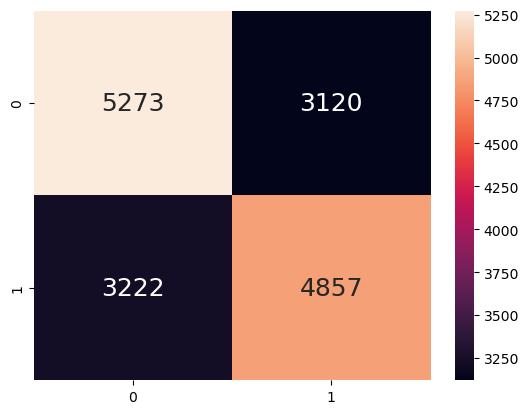


=== KNN ===
Accuracy: 0.5745507527926178
              precision    recall  f1-score   support

           0       0.58      0.58      0.58      8393
           1       0.57      0.57      0.57      8079

    accuracy                           0.57     16472
   macro avg       0.57      0.57      0.57     16472
weighted avg       0.57      0.57      0.57     16472

[[4862 3531]
 [3477 4602]]


<Axes: >

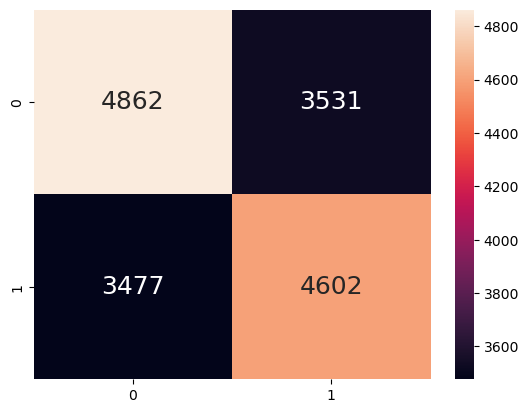

In [94]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

from sklearn.metrics import confusion_matrix
sb.heatmap(confusion_matrix(y_test,lr_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18})

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

print("\n=== KNN ===")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))


# Plot the two-way Confusion Matrix
from sklearn.metrics import confusion_matrix
sb.heatmap(confusion_matrix(y_test, knn_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}